<a href="https://colab.research.google.com/github/shaipshiverya/Data_Analysis_python_projects/blob/main/netflix_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Netflix Content Analysis — Catalog & Strategy Insights
## A Media/OTT Analytics Project

**Domain:** Media & Entertainment (OTT)  
**Dataset:** Netflix Titles — Movies & TV Shows catalog

---

### 🎯 Business Problem
Netflix has grown to become one of the world's leading streaming platforms, hosting thousands of titles spanning movies, TV shows, and original productions across the globe. Content strategy teams need to understand **what's already in the catalog** — content mix, geographic origins, genre popularity, ratings, and release trends — to guide future acquisition, production, and licensing decisions.

This project analyzes Netflix's content library to answer: **where does Netflix's content come from, what genres and ratings dominate, how has content growth trended over time, and who are the most prolific contributors?**

**End Users:** Content strategy & acquisitions teams

### 📋 Project Workflow
1. Data Loading & Understanding
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis — Content Mix, Geography, Genre, Ratings, Trends, Top Contributors
5. Simple Prediction Model — Movie vs TV Show Classifier
6. Model Explainability — SHAP
7. Key Findings & Business Recommendations

---


## 📦 Section 1: Setup — Import Libraries & Load Data


In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Load the dataset


In [123]:
df = pd.read_csv('/content/netflix dataset.zip')

In [124]:
# First five rows

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [125]:
#Sample of the data file

df.sample(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8178,s8179,Movie,The Accountant of Auschwitz,Matthew Shoychet,NaN,Canada,"July 1, 2019",2018,TV-14,78 min,"Documentaries, International Movies","Decades after WWII, a former SS officer stands..."
675,s676,TV Show,REA(L)OVE,NaN,"Atsushi Tamura, Mari Yaguchi",Japan,"June 19, 2021",2018,TV-MA,1 Season,"International TV Shows, Reality TV, Romantic T...","A group of men and women, each burdened with a..."
7356,s7357,Movie,Loving Annabelle,Katherine Brooks,"Erin Kelly, Diane Gaidry, Laura Breckenridge, ...",United States,"July 1, 2018",2006,TV-MA,77 min,"Dramas, Independent Movies, LGBTQ Movies",An esteemed young poetry teacher at a Catholic...
6968,s6969,Movie,Highly Strung,Scott Hicks,NaN,Australia,"February 1, 2017",2015,TV-14,80 min,"Documentaries, International Movies, Music & M...",Fiery passions take center stage in this intim...
2032,s2033,TV Show,Get Organized with The Home Edit,NaN,NaN,United States,"September 9, 2020",2020,TV-PG,1 Season,Reality TV,Expert home organizers Clea and Joanna help ce...
7184,s7185,TV Show,Khan: No. 1 Crime Hunter,NaN,Rajesh Sharma,India,"May 1, 2018",2018,TV-14,1 Season,"Crime TV Shows, International TV Shows, TV Com...","From fake marriages to online shopping fraud, ..."
2849,s2850,Movie,Taylor Tomlinson: Quarter-Life Crisis,Marcus Raboy,Taylor Tomlinson,United States,"March 3, 2020",2020,TV-MA,61 min,Stand-Up Comedy,She's halfway through her 20s — and she's over...
8082,s8083,Movie,Star Wars: Episode VIII: The Last Jedi,Rian Johnson,"Mark Hamill, Carrie Fisher, Adam Driver, Daisy...",United States,"June 26, 2018",2017,PG-13,152 min,"Action & Adventure, Children & Family Movies, ...",As the remnants of the Resistance flee Kylo Re...
7839,s7840,Movie,Rebel Without a Cause,Nicholas Ray,"James Dean, Natalie Wood, Sal Mineo, Jim Backu...",United States,"November 1, 2019",1955,PG-13,111 min,"Classic Movies, Dramas",When Jim Stark arrives in a new town with his ...
518,s519,Movie,Har Kisse Ke Hisse: Kaamyaab,Hardik Mehta,"Sanjay Mishra, Deepak Dobriyal, Sarika Singh, ...",India,"July 6, 2021",2020,TV-14,105 min,"Dramas, International Movies","After a career of thankless credits, a retired..."


In [126]:
# Statistical distribution of the data

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [128]:
# Looking for the null values in the dataset

df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## 🧹 Section 2: Data Cleaning & Preprocessing

### Imputing Missing Values


In [129]:
df['director']=df['director'].fillna('unknown')
df['cast']=df['cast'].fillna('unknown')
df['country']=df['country'].fillna('unknown')
df['rating']=df['rating'].fillna('not rated')

In [130]:
# check for null values again

df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,3


In [131]:
# number of rows and columns

df.shape

(8807, 12)

### Dropping Remaining Nulls & Duplicates


In [132]:
df.dropna(subset = ['duration'],inplace= True)

In [133]:
df.drop_duplicates(inplace= True)

In [134]:
# Standardizing the Duration Column

df["duration"]=df['duration'].str.replace('min',"").str.replace("Seasons","").str.replace("Season","")

In [135]:
# Standardising the date column for further analysis

df["date_added"]  = pd.to_datetime(df["date_added"],format = "mixed")
df["date_added"]

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24
...,...
8802,2019-11-20
8803,2019-07-01
8804,2019-11-01
8805,2020-01-11


## 📊 Section 3: Exploratory Data Analysis (EDA)


### 3.1 — Movies vs TV Shows Distribution


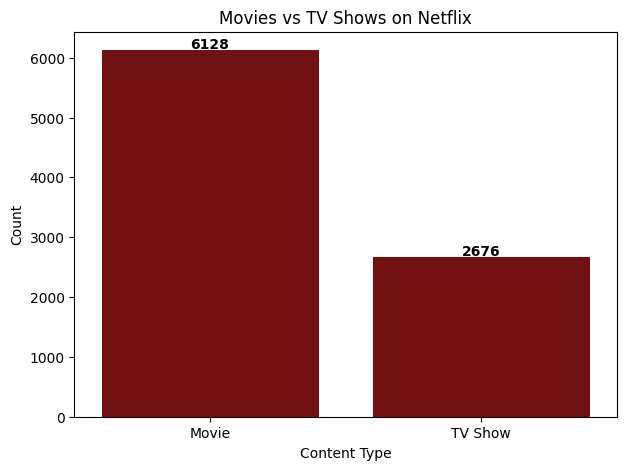

In [137]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x='type', color='maroon')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 20,
            str(int(p.get_height())), ha='center', fontweight='bold')

plt.show()


**💡 Insight:** Movies significantly outnumber TV Shows in the catalog — useful context for understanding Netflix's content mix strategy and where future investment might shift the balance.


### 3.2 — Countries Producing the Most Content


In [138]:
df['country'].value_counts().head(20)



,count
country,
United States,2815
India,972
unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


/tmp/ipykernel_4061/4071877807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='country', order=df['country'].value_counts().head(12).index, palette='viridis')


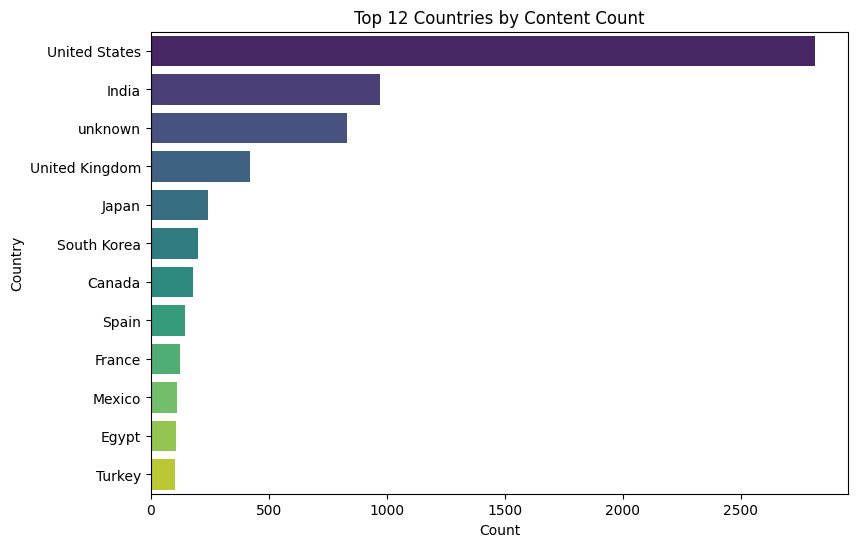

In [139]:
plt.figure(figsize=(9,6))

sns.countplot(data=df, y='country', order=df['country'].value_counts().head(12).index, palette='viridis')

plt.title('Top 12 Countries by Content Count')
plt.xlabel('Count')
plt.ylabel('Country')

plt.show()

**💡 Insight:** The United States dominates content production, with India and the UK as other major contributors — this concentration highlights both Netflix's content origin and potential opportunity for further international expansion.


### 3.3 — Most Popular Genres


In [140]:
genre = df['listed_in'].str.split(",").explode("listed_in")
genre.value_counts(ascending= False)

,count
listed_in,
International Movies,2624
Dramas,1600
Comedies,1210
Action & Adventure,859
Documentaries,829
...,...
Romantic Movies,3
Spanish-Language TV Shows,2
LGBTQ Movies,1


/tmp/ipykernel_4061/2807007685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=genre, order=genre.value_counts().head(20).index, palette='mako')


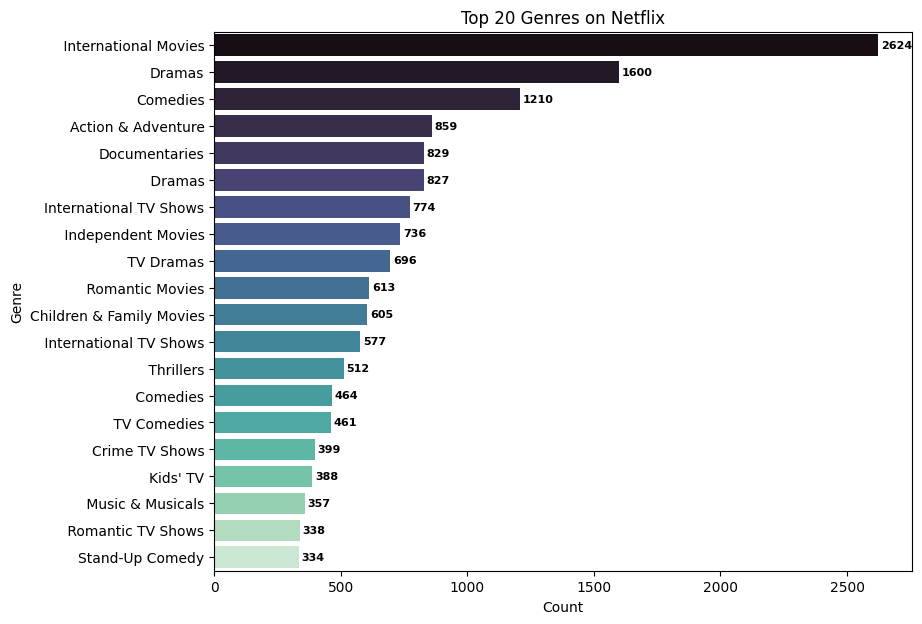

In [141]:
plt.figure(figsize=(9,7))

ax = sns.countplot(y=genre, order=genre.value_counts().head(20).index, palette='mako')

plt.title('Top 20 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')

for p in ax.patches:
    ax.text(p.get_width() + 10, p.get_y() + p.get_height()/2,
            str(int(p.get_width())), va='center', fontsize=8, fontweight='bold')

plt.show()


**💡 Insight:** Dramas and International content lead genre counts, showing Netflix's catalog leans toward broad, internationally appealing categories rather than niche genres — useful for prioritizing future licensing deals.


### 3.4 — Content Rating Distribution


In [142]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


/tmp/ipykernel_4061/1119630841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='crest')


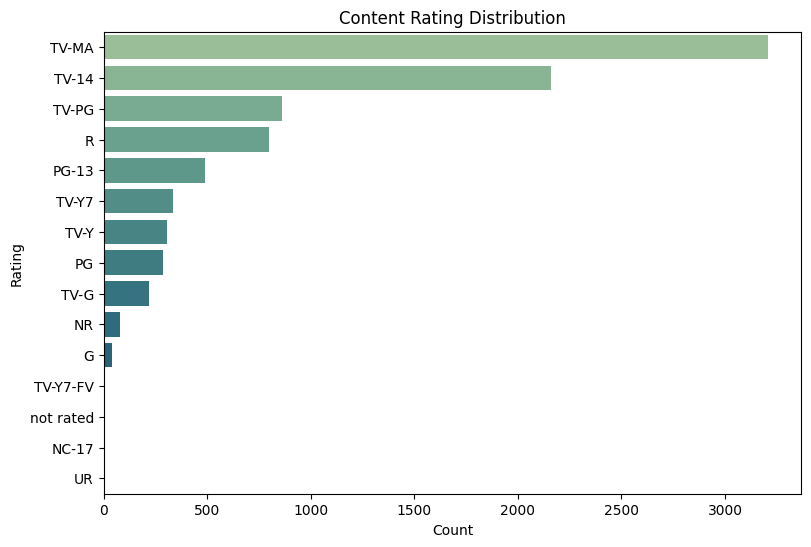

In [143]:
plt.figure(figsize=(9,6))

sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='crest')

plt.title('Content Rating Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()


**💡 Insight:** TV-MA and TV-14 dominate the rating distribution, indicating Netflix's catalog skews toward mature and teen audiences rather than young children — relevant for content acquisition targeting specific demographics.


### 3.5 — Release Year Trend (Top 10 Years)


In [144]:
rel_year = df['release_year'].value_counts(ascending= False).head(10)
rel_year

,count
release_year,
2018,1147
2017,1031
2019,1030
2020,953
2016,902
2021,592
2015,559
2014,352
2013,288


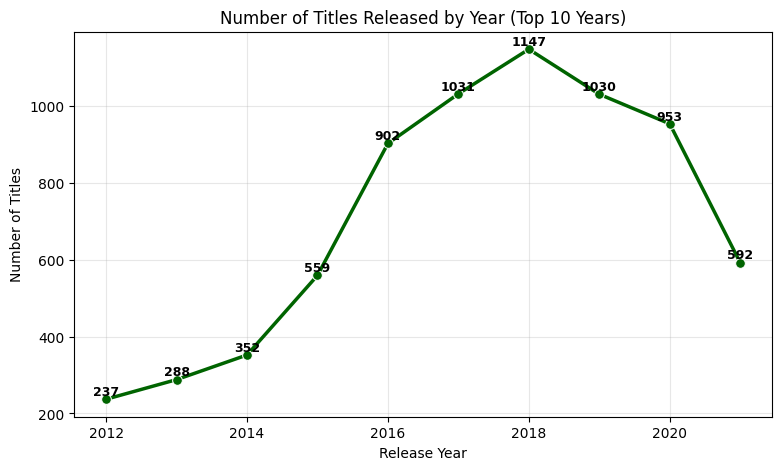

In [145]:
plt.figure(figsize=(9,5))

ax = sns.lineplot(x=rel_year.index, y=rel_year.values, color='darkgreen', marker='o', linewidth=2.5, markersize=7)

plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.title('Number of Titles Released by Year (Top 10 Years)')
plt.grid(alpha=0.3)

for x, y in zip(rel_year.index, rel_year.values):
    ax.text(x, y + 10, str(y), ha='center', fontsize=9, fontweight='bold')

plt.show()


**💡 Insight:** Netflix's content output grew sharply after 2015, reflecting the platform's aggressive push into original programming and global content acquisition during that period — useful context for understanding current catalog depth by era.


### 3.6 — Top Directors & Actors on Netflix


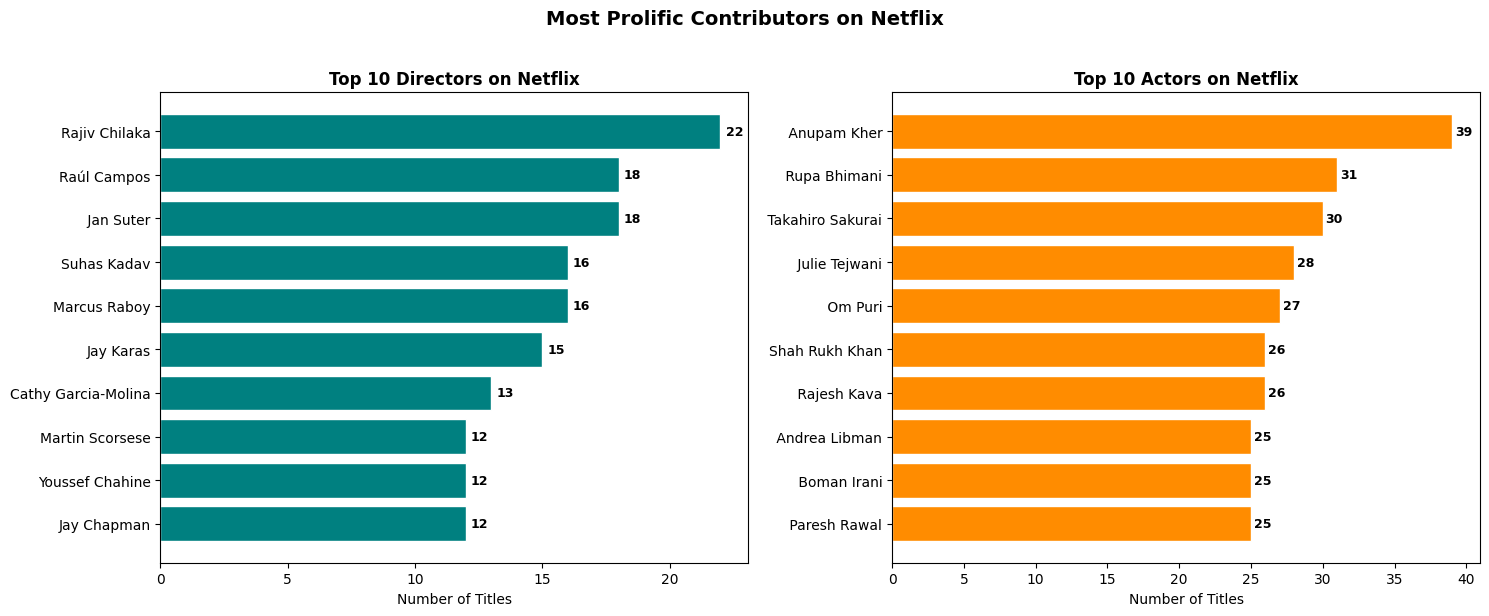

In [146]:
top_directors = df['director'].str.split(",").explode().value_counts()[1:11]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top_directors.index[::-1], top_directors.values[::-1],
             color='teal', edgecolor='white')
axes[0].set_title('Top 10 Directors on Netflix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Titles')
for i, v in enumerate(top_directors.values[::-1]):
    axes[0].text(v + 0.2, i, str(v), va='center', fontsize=9, fontweight='bold')

top_actors = df['cast'].str.split(",").explode().value_counts(ascending=False)[1:11]
axes[1].barh(top_actors.index[::-1], top_actors.values[::-1],
             color='darkorange', edgecolor='white')
axes[1].set_title('Top 10 Actors on Netflix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Titles')
for i, v in enumerate(top_actors.values[::-1]):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=9, fontweight='bold')

plt.suptitle('Most Prolific Contributors on Netflix', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**💡 Insight:** A small number of directors and actors appear disproportionately often across the Netflix catalog — these recurring names point to long-standing content partnerships and could guide future deal renewals or co-production opportunities.


## 🤖 Section 5: Simple Prediction Model — Movie vs TV Show Classifier

Beyond descriptive EDA, a simple classification model can predict whether a title is a **Movie or TV Show** based on its genre, duration, rating, and release year. This kind of model could help auto-categorize new or mislabeled catalog entries.

We use **Logistic Regression** — chosen for simplicity and interpretability rather than raw performance.

### Strategy:
- **Features:** primary genre, duration (numeric), rating, release year
- **Target:** `type` (Movie / TV Show)
- **Train/Test split:** 80% training, 20% testing
- **Scaling:** StandardScaler (Logistic Regression needs scaled numeric features)


In [147]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df_model = df.copy()

# Use primary (first-listed) genre only, to keep feature space manageable
df_model['primary_genre'] = df_model['listed_in'].str.split(',').str[0]

# Convert duration to numeric (already stripped of text earlier)
df_model['duration'] = pd.to_numeric(df_model['duration'], errors='coerce')
df_model = df_model.dropna(subset=['duration', 'rating', 'primary_genre'])

# Encode categorical columns
le_genre  = LabelEncoder()
le_rating = LabelEncoder()
df_model['genre_enc']  = le_genre.fit_transform(df_model['primary_genre'])
df_model['rating_enc'] = le_rating.fit_transform(df_model['rating'])

X = df_model[['genre_enc', 'rating_enc', 'duration', 'release_year']]
y = (df_model['type'] == 'TV Show').astype(int)   # 1 = TV Show, 0 = Movie

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'TV Show proportion in train: {y_train.mean()*100:.1f}%')


Train size: 7,043 | Test size: 1,761
TV Show proportion in train: 30.4%


In [148]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f'✅ Logistic Regression trained')
print(f'Accuracy: {acc:.2%}')
print()
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))


✅ Logistic Regression trained
Accuracy: 99.89%

              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1226
     TV Show       1.00      1.00      1.00       535

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



**💡 Why `class_weight='balanced'`?**  
Movies significantly outnumber TV Shows in the catalog (per Section 3.1). Without balancing, the model would lean toward always predicting "Movie" and still look accurate. This setting forces it to pay attention to both classes.


### 5.1 — Confusion Matrix

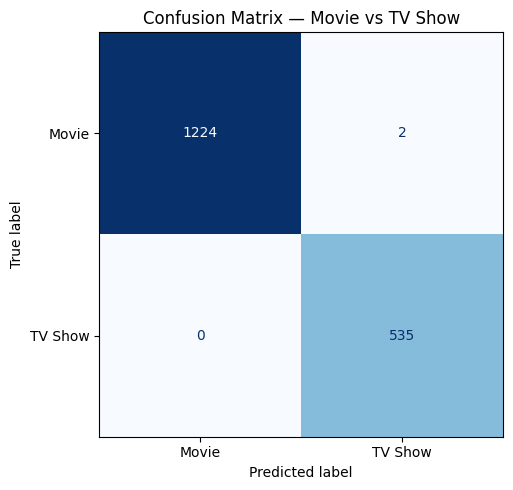

In [149]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Movie', 'TV Show'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Movie vs TV Show')
plt.tight_layout()
plt.show()


### 5.2 — Feature Coefficients

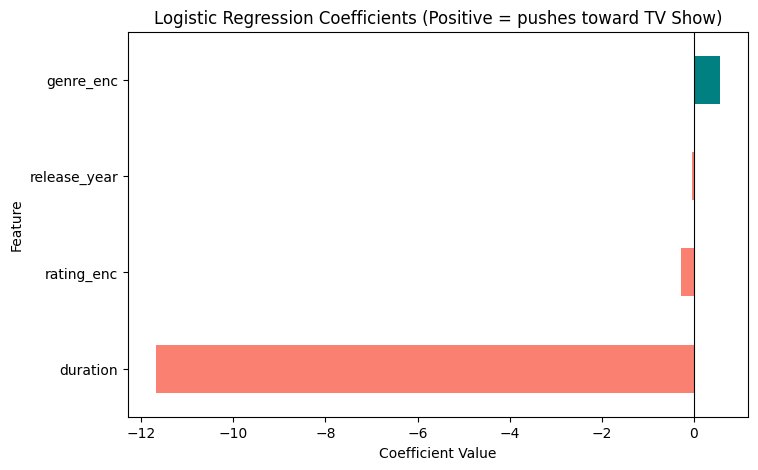

In [150]:
coef_df = pd.Series(log_model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8,5))

bar_colors = ['teal' if v > 0 else 'salmon' for v in coef_df.values]
coef_df.plot(kind='barh', color=bar_colors)

plt.title('Logistic Regression Coefficients (Positive = pushes toward TV Show)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)

plt.show()


**💡 Insight:** Duration is naturally the strongest signal — TV Shows are measured in seasons while Movies are measured in minutes, so this feature alone captures most of the distinction. Genre and rating add secondary signal, helping the model separate edge cases.


## 🔍 Section 6: Model Explainability — SHAP

SHAP shows which features matter most across all predictions — useful for explaining the model to non-technical stakeholders.


In [151]:
import shap

explainer = shap.LinearExplainer(log_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print('✅ SHAP values computed')
print(f'Shape: {shap_values.shape}')


✅ SHAP values computed
Shape: (1761, 4)


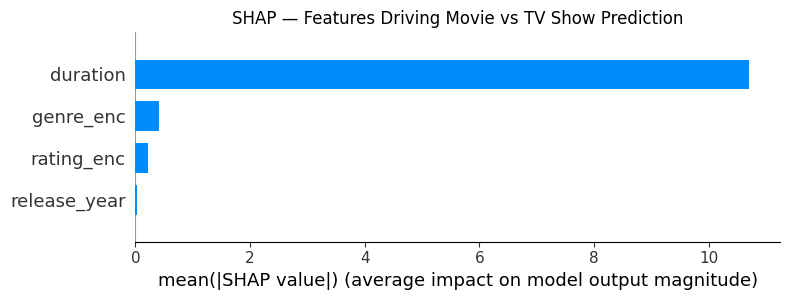

In [152]:
plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP — Features Driving Movie vs TV Show Prediction')
plt.tight_layout()
plt.show()


**💡 SHAP Top Predictors:**

| Rank | Feature | Business Meaning |
|------|---------|-------------------|
| 🥇 1 | `duration` | TV Shows (seasons) vs Movies (minutes) — the dominant structural signal |
| 🥈 2 | `genre_enc` | Certain genres lean more TV Show or Movie (e.g. Sitcoms vs Action films) |
| 🥉 3 | `rating_enc` | Ratings like TV-MA/TV-14 are more common in TV Shows than Movies |
| 4 | `release_year` | Weak signal — recency has only a minor effect on content type |


## ✅ Section 7: Key Findings & Business Recommendations

### 🔬 Key Findings
1. **Netflix hosts significantly more Movies than TV Shows** in its catalog
2. **The United States produces the highest number of Netflix titles**, followed by India and the UK
3. **Dramas and International content are the most common genres**, reflecting a broad-appeal content strategy
4. **TV-MA is one of the most common ratings**, indicating a catalog skewed toward mature audiences
5. **Netflix content production increased rapidly after 2015**, coinciding with the platform's original content push
6. **A small group of directors and actors appear repeatedly** across the catalog, signaling recurring content partnerships
7. **Duration is the strongest signal separating Movies from TV Shows** — confirmed by both model coefficients and SHAP, since the two formats are measured differently (minutes vs seasons)

---

### 💼 Business Recommendations

**1. Balance the Movie-TV Show Mix**  
Given TV Shows tend to drive higher long-term engagement and retention through episodic viewing, Netflix should evaluate whether increasing TV Show investment relative to Movies could improve subscriber retention metrics.

**2. Expand Beyond Top Content-Producing Countries**  
While the US dominates content volume, growth markets may be underrepresented. A deeper investment in non-US regional content (beyond India and the UK) could capture audiences in underserved international markets.

**3. Diversify Genre Investment**  
With Drama and International content already saturated, exploring underrepresented but growing genres (e.g., true crime, animation) could differentiate Netflix's catalog from competitors.

**4. Expand Content for Younger Audience Ratings**  
Since the catalog skews toward mature ratings (TV-MA, TV-14), there may be an underserved opportunity in family and younger-audience content to broaden subscriber demographics.

**5. Strengthen Partnerships with Recurring Directors & Actors**  
The most prolific directors and actors represent proven, repeatable content partnerships. Prioritizing renewal deals and co-production opportunities with these names reduces content risk and leverages established audience trust.

**6. Use the Classifier for Catalog Quality Checks**  
The Movie vs TV Show model can be repurposed as a lightweight data-quality tool — flagging titles where the predicted type disagrees with the labeled type, helping catch mislabeled catalog entries at scale.

---

> **Bottom line:** Netflix's catalog reflects a mature, US-centric, drama-heavy content strategy. The clearest growth opportunities lie in diversifying genre mix, expanding underrepresented regions, and deepening relationships with proven content creators.

---
*Tools: Python, pandas, matplotlib, seaborn, scikit-learn, SHAP | Domain: Media & Entertainment (OTT)*
